In [1]:
import numpy as np
import pandas as pd
import torch
import os
import grelu.resources
import wandb
import time



/Users/elizabeth.gilfeather/miniforge3/envs/pgm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Setting Up Borzoi

In [2]:
grelu.resources.artifacts("borzoi", type_is="model")

wandb: Currently logged in as: anony-moose-155375741509270062 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


['human_fold3',
 'human_fold2',
 'human_fold1',
 'human_fold0',
 'mouse_rep3',
 'mouse_rep2',
 'mouse_rep1',
 'mouse_rep0',
 'human_rep3',
 'human_rep2',
 'human_rep1',
 'human_rep0']

In [3]:
model = grelu.resources.load_model(
    project="borzoi",
    model_name="human_rep0",
)
#torch.save(model, "./full_models/borzoi_human_rep0.pt")



wandb: Downloading large artifact 'human_rep0:latest', 711.80MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.7 (1065.9MB/s)


In [ ]:
from borzoi_lora_arch_mha import EnformerModel
scratch_model = EnformerModel(k_l=2, n_tasks=5313, crop_len=320, final_act_func="softplus", final_pool_func=None)
scratch_model

EnformerModel(
  (embedding): EnformerTrunk(
    (conv_tower): EnformerConvTower(
      (blocks): ModuleList(
        (0): Sequential(
          (0): LoraConv1d(
            (layer): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=(7,))
          )
          (1): ConvBlock(
            (norm): Norm(
              (layer): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (conv): LoraConv1d(
              (layer): Conv1d(768, 768, kernel_size=(1,), stride=(1,))
            )
            (act): Activation(
              (layer): GELU()
            )
            (pool): Pool(
              (layer): AttentionPool(
                (to_attn_logits): Conv2d(768, 768, kernel_size=(1, 1), stride=(1, 1), bias=False)
              )
            )
            (dropout): Dropout(
              (layer): Identity()
            )
            (channel_transform): ChannelTransform(
              (layer): Identity()
            )
          )

In [ ]:
from borzoi_lora_arch_mha import BorzoiModel
scratch_model = BorzoiModel(k_l=256, n_tasks=7611, crop_len=5120, final_act_func="softplus", final_pool_func=None)
scratch_model

BorzoiModel(
  (embedding): BorzoiTrunk(
    (conv_tower): BorzoiConvTower(
      (blocks): ModuleList(
        (0): Stem(
          (conv): WrappedConv1d(
            (layer): Conv1d(4, 512, kernel_size=(15,), stride=(1,), padding=(7,))
          )
          (act): Activation(
            (layer): Identity()
          )
          (pool): Pool(
            (layer): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          )
        )
        (1): ConvBlock(
          (norm): Norm(
            (layer): BatchNorm1d(512, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          )
          (conv): WrappedConv1d(
            (layer): Conv1d(512, 608, kernel_size=(5,), stride=(1,), padding=(2,))
          )
          (act): Activation(
            (layer): GELU(approximate='tanh')
          )
          (pool): Pool(
            (layer): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          )
          (dropout): Dropo

In [12]:
model.data_params['train'].keys()
model.data_params['train']["seq_len"]

524288

## Lora Linear and Conv for Borzoi

In [4]:
import torch
from torch import Tensor, nn
from scipy.sparse.linalg import svds
import torch
import numpy as np



import copy



def convert_to_lora_proper(model, linear_rank=16):
    new_model = copy.deepcopy(model)  # clone entire model

    def replace_layers(module):
        for name, child in module.named_children():
            # if name == "mha":
            #     continue  
            replace_layers(child)
            if isinstance(child, nn.Linear):
                max_k = min(child.in_features, child.out_features)
                if linear_rank < max_k:
                    setattr(module, name, LoraLinear(child, k=linear_rank))
            elif isinstance(child, nn.Conv1d):
                setattr(module, name, WrappedConv1d(child))

    replace_layers(new_model)
    return new_model





class LoraLinear(nn.Module):
    def __init__(self, layer: nn.Linear, k: int = 16):
        super().__init__()
        self.in_features = layer.in_features
        self.out_features = layer.out_features
        
        self.w = layer.weight.detach().cpu().numpy()
        self.b = None if layer.bias is None else layer.bias.detach().cpu().numpy()
        self.out_dim, self.in_dim = self.w.shape

        # Clamp k to valid range
        max_k = min(self.in_dim, self.out_dim) - 1  # svds requires k < min(A.shape)
        if k > max_k:
            print(f"[LoraLinear] Requested rank {k} too large, using k={max_k}")
            k = max_k
        if k <= 0:
            raise ValueError(f"[LoraLinear] Cannot apply LoRA: k={k} <= 0 for layer {layer}")
        self.k = k

        # LoRA layers
        

        # Initialize weights
        w11, w12, b = self.make_layer()

        self.loraw11 = nn.Linear(self.in_dim, self.k, bias=False)
        if b is not None:
            self.loraw12 = nn.Linear(self.k, self.out_dim)
        else:
            self.loraw12 = nn.Linear(self.k, self.out_dim, bias = False)


        self.loraw11.weight.data = w11.clone()
        self.loraw12.weight.data = w12.clone()

        if b is not None:
            self.loraw12.bias.data = b.clone()

        
        del self.w
        del self.b

    def make_layer(self):
        U, S, Vt = svds(self.w, k=self.k)
        Uk = U[:,-self.k:].copy()
        Sk = S[-self.k:].copy()
        Vtk = Vt[-self.k:,:].copy()

        w11 = np.diag(np.sqrt(S)) @ Vt  # [k, in_dim]
        w12 = U @ np.diag(np.sqrt(S))    # [out_dim, k]

        w11pt = torch.from_numpy(w11).float()
        w12pt = torch.from_numpy(w12).float()
        bpt = None if self.b is None else torch.from_numpy(self.b).float()
        return w11pt, w12pt, bpt

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.loraw11(x)
        x = self.loraw12(x)
        return x



class WrappedConv1d(nn.Module):
    def __init__(self, layer: nn.Conv1d):

        super().__init__()
        assert isinstance(layer, nn.Conv1d), "Expected nn.Conv1d layer"
      
        # Keep original layer as-is
        self.skip_lora = True
        self.layer = layer
        return

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        return self.layer(x)
     

 



In [5]:
lora_borzoi_linear = convert_to_lora_proper(model, linear_rank=256)
print(lora_borzoi_linear)
print(model)

LightningModel(
  (model): BorzoiModel(
    (embedding): BorzoiTrunk(
      (conv_tower): BorzoiConvTower(
        (blocks): ModuleList(
          (0): Stem(
            (conv): WrappedConv1d(
              (layer): Conv1d(4, 512, kernel_size=(15,), stride=(1,), padding=same)
            )
            (act): Activation(
              (layer): Identity()
            )
            (pool): Pool(
              (layer): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
            )
          )
          (1): ConvBlock(
            (norm): Norm(
              (layer): BatchNorm1d(512, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            )
            (conv): WrappedConv1d(
              (layer): Conv1d(512, 608, kernel_size=(5,), stride=(1,), padding=same)
            )
            (act): Activation(
              (layer): GELU(approximate='tanh')
            )
            (pool): Pool(
              (layer): MaxPool1d(kernel_size=2, stride=2,

In [ ]:
import torch
import time
import json
import os
import numpy as np
from tqdm import tqdm
from scipy.stats import pearsonr
import torch
from torch.utils.data import Dataset, DataLoader
class SeqDataset(Dataset):
    def __init__(self, sequences):
        """
        sequences: list of strings
        """
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def benchmark_model(model, loader, baseline_preds, linear_rank, input_shape, device="cuda", runs=5, outfile="borzoi_benchmark_results.json"):
    """
    Convert model with LoRA, time forward pass, log params + timing + metrics.
    Appends results to a JSON file.
    """
    save_dir = "./borzoi_lora_weights/"

    # Convert model with LoRA ranks
    new_model = convert_to_lora_proper(model, linear_rank=linear_rank)
    new_model.eval()

    if linear_rank == 1000000000:
        linear_rank = "full"
    lora_fname = f"{save_dir}borzoi_lora_lr{lr}.pth"
    state_dict = new_model.state_dict()
    new_state_dict = {key.replace("model.", ""): value for key, value in state_dict.items()}
    torch.save(new_state_dict, lora_fname)
    print(f"Saved LoRA weights: {lora_fname}")

    # Count total trainable params
    total_params = sum(p.numel() for p in new_model.parameters() if p.requires_grad)

    # ---- Compute metrics vs baseline ----
    sum_pearson = None
    sum_mse = None
    num_batches = 0

    for batch_idx, batch_seqs in enumerate(loader):
        batch_seqs = list(batch_seqs)

        preds1 = baseline_preds[batch_idx]
        preds2 = new_model.predict_on_seqs(batch_seqs, device=device)

        B, T, L = preds1.shape
        preds1_flat = preds1.reshape(B, T, L)
        preds2_flat = preds2.reshape(B, T, L)

        if sum_pearson is None:
            sum_pearson = np.zeros(T)
            sum_mse = np.zeros(T)

        for t in range(T):
            p1 = preds1_flat[:, t, :].ravel()
            p2 = preds2_flat[:, t, :].ravel()
            sum_pearson[t] += pearsonr(p1, p2)[0]
            sum_mse[t] += np.mean((p1 - p2) ** 2)

        num_batches += 1

    mean_pearson_per_task = sum_pearson / num_batches
    mean_mse_per_task = sum_mse / num_batches

    mean_pearson = float(np.nanmean(mean_pearson_per_task))
    mean_mse = float(np.nanmean(mean_mse_per_task))

    # ---- Package results ----
    result = {
        "linear_rank": linear_rank,
        "n_blocks": "mha",   
        "total_params": total_params,
        "mean_pearson": mean_pearson,
        "mean_mse": mean_mse,
    }

    # Append to JSON file
    if os.path.exists(outfile):
        with open(outfile, "r") as f:
            all_results = json.load(f)
    else:
        all_results = []

    all_results.append(result)

    with open(outfile, "w") as f:
        json.dump(all_results, f, indent=2)

    print(f"Logged benchmark: {result}")

borzoi_test_df = pd.DataFrame(model.data_params['val']['intervals'])

borzoi_test_df = borzoi_test_df[borzoi_test_df['start'] >= 1].reset_index(drop=True)
input_seqs = grelu.sequence.format.convert_input_type(
    borzoi_test_df,
    output_type="strings",
    genome="hg38"
)
dataset = SeqDataset(input_seqs[:8])
loader = DataLoader(dataset, batch_size=4, shuffle=False)
baseline_preds = []
for batch_seqs in tqdm(loader, desc="Baseline predictions"):
    batch_seqs = list(batch_seqs)
    preds = model.predict_on_seqs(batch_seqs, device="cpu")  # or device
    baseline_preds.append(preds)

# Example sweep
linear_ranks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 1000000000] # rename 1000000000 to full
input_shape = (4, 4, 524288)  # batch=4

for lr in linear_ranks:
    benchmark_model(model, loader, baseline_preds, linear_rank=lr, input_shape=input_shape, device="cpu", runs=1, outfile="borzoi_benchmark_results_mha.json")


Baseline predictions: 100%|██████████| 2/2 [01:10<00:00, 35.30s/it]


✅ Logged benchmark: {'linear_rank': 128, 'conv_rank': 128, 'n_blocks': 'mha', 'total_params': 28298843, 'avg_time_per_sequence_ms': 2879.782408475876, 'mean_pearson': 0.0010683081905721761, 'mean_mse': 2.4531732466182863}
✅ Logged benchmark: {'linear_rank': 128, 'conv_rank': 256, 'n_blocks': 'mha', 'total_params': 36326363, 'avg_time_per_sequence_ms': 3207.8050673007965, 'mean_pearson': 0.28917025509787203, 'mean_mse': 2.2545298004358263}
✅ Logged benchmark: {'linear_rank': 128, 'conv_rank': 512, 'n_blocks': 'mha', 'total_params': 52381403, 'avg_time_per_sequence_ms': 3610.024243593216, 'mean_pearson': 0.8437074924113246, 'mean_mse': 0.7436729043179886}
✅ Logged benchmark: {'linear_rank': 128, 'conv_rank': 1024, 'n_blocks': 'mha', 'total_params': 79786203, 'avg_time_per_sequence_ms': 3850.6047427654266, 'mean_pearson': 0.9484280426040019, 'mean_mse': 0.10486045243558004}
✅ Logged benchmark: {'linear_rank': 128, 'conv_rank': 1000000000, 'n_blocks': 'mha', 'total_params': 80007003, 'avg_

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
class SeqDataset(Dataset):
    def __init__(self, sequences):
        """
        sequences: list of strings
        """
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

In [11]:
batch_size = 1 # adjust based on GPU memory

dataset = SeqDataset(input_seqs[:16])
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [16]:
torch.cuda.empty_cache()

In [ ]:
device = "cpu"
 # We'll get exact num_tasks later
sum_pearson = None
sum_mse = None
num_batches = 0
from tqdm import tqdm
from scipy.stats import pearsonr


for batch_seqs in tqdm(loader, desc="Predicting batches"):
    # batch_seqs is a list of strings, convert to Python list
    batch_seqs = list(batch_seqs)
    
    preds1 = model.predict_on_seqs(batch_seqs, device=device)
    preds2 = lora_model[0].predict_on_seqs(batch_seqs, device=device)
    
    B, T, L = preds1.shape
    preds1_flat = preds1.reshape(B, T, L)
    preds2_flat = preds2.reshape(B, T, L)


    if sum_pearson is None:
        sum_pearson = np.zeros(T)
        sum_mse = np.zeros(T)
    
    # Compute per-task metrics
    for t in range(T):
        p1 = preds1_flat[:, t, :].ravel()
        p2 = preds2_flat[:, t, :].ravel()
        sum_pearson[t] += pearsonr(p1, p2)[0]
        sum_mse[t] += np.mean((p1 - p2)**2)
    
    num_batches += 1
mean_pearson_per_task = sum_pearson / num_batches
mean_mse_per_task = sum_mse / num_batches

print("Mean Pearson correlation across tasks:", np.mean(mean_pearson_per_task))
print("Mean MSE across tasks:", np.mean(mean_mse_per_task))

Predicting batches: 100%|██████████| 16/16 [04:00<00:00, 15.04s/it]


In [31]:
import grelu.visualize
%matplotlib inline

In [32]:
tasks = pd.DataFrame(model.data_params['tasks'])
output_intervals = model.input_intervals_to_output_intervals(borzoi_test_df.head(200).tail(1))
print(output_intervals)
output_start = output_intervals.start[199]
output_end = output_intervals.end[199]
output_len = output_end - output_start
rna_brain_tasks = tasks[(tasks.assay=="RNA") & (tasks["sample"].str.contains("brain"))].head(2)

tasks_to_plot = rna_brain_tasks.index.tolist()
task_names = tasks.description[tasks_to_plot].tolist() # Description of these tracks from the `tasks` dataframe

print(tasks_to_plot)
print(task_names)

    chrom    start      end
199  chr4  2277493  2474101
[6635, 6636]
['RNA:brain tissue female adult (66 years)', 'RNA:brain tissue female adult (66 years)']


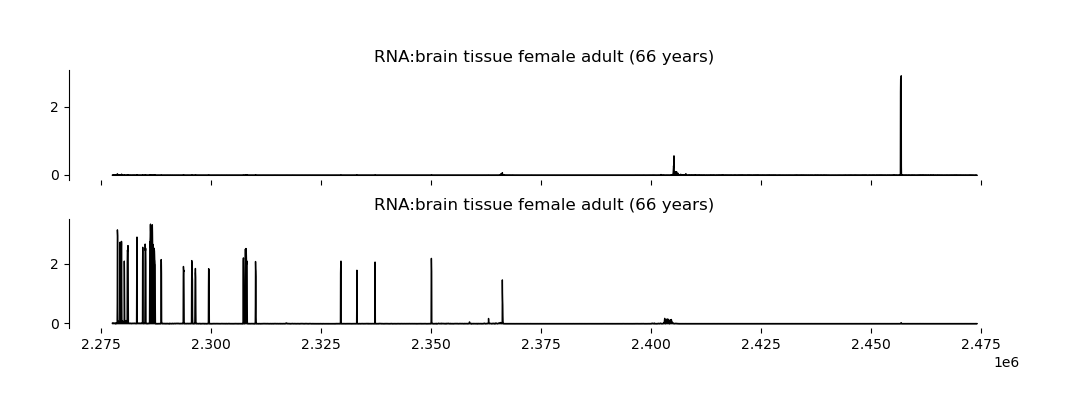

In [62]:
fig = grelu.visualize.plot_tracks(
    preds1[0, tasks_to_plot, :], # Outputs to plot
    start_pos=output_start, # Start coordinate for the x-axis label
    end_pos=output_end, # End coordinate for the x-axis label
    titles=task_names, # titles for each track
    figsize=(10, 3.5), # width, height
)

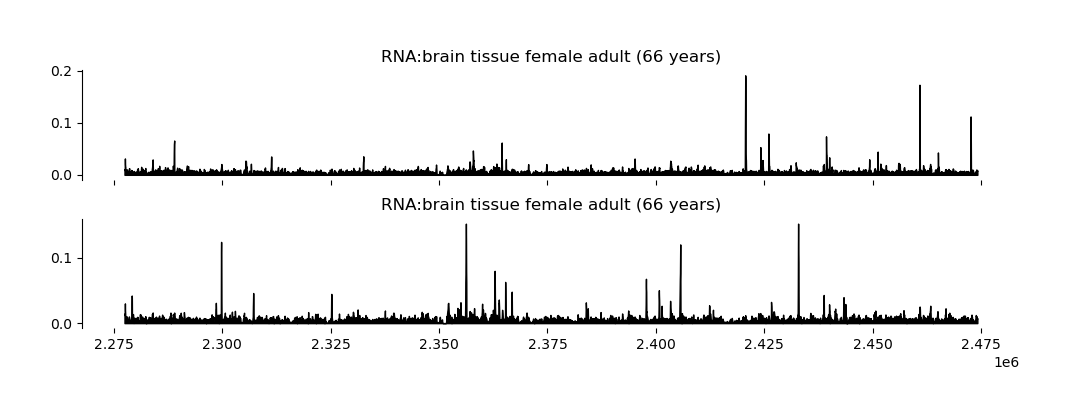

In [33]:

fig = grelu.visualize.plot_tracks(
    preds2[0, tasks_to_plot, :], # Outputs to plot
    start_pos=output_start, # Start coordinate for the x-axis label
    end_pos=output_end, # End coordinate for the x-axis label
    titles=task_names, # titles for each track
    figsize=(10, 3.5), # width, height
)

## Lora for Enformer


In [5]:
grelu.resources.artifacts("enformer", type_is="model")

wandb: Currently logged in as: anony-moose-155375741509270062 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


['mouse', 'human']

In [4]:
model = grelu.resources.load_model(
    project="enformer",
    model_name="human",
)

wandb: Currently logged in as: anony-moose-155375741509270062 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'human:latest', 941.03MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.8 (1182.1MB/s)


In [5]:
model.data_params['train'].items()

dict_items([('seq_len', 196608), ('label_len', 114688), ('genome', 'hg38'), ('bin_size', 128), ('max_seq_shift', 3), ('rc', True), ('intervals', {'chrom': ['chr18', 'chr4', 'chr11', 'chr16', 'chr3', 'chr7', 'chr8', 'chr21', 'chr16', 'chr8', 'chr4', 'chr17', 'chr2', 'chr2', 'chr9', 'chr19', 'chr8', 'chr9', 'chr4', 'chr17', 'chr3', 'chr8', 'chr16', 'chr2', 'chr6', 'chr15', 'chr5', 'chr12', 'chr10', 'chr1', 'chr1', 'chr2', 'chr17', 'chr11', 'chr20', 'chr2', 'chr6', 'chr6', 'chr18', 'chr11', 'chr7', 'chr4', 'chr18', 'chr2', 'chr1', 'chr1', 'chr6', 'chr7', 'chr7', 'chr10', 'chr18', 'chr17', 'chr15', 'chr1', 'chr9', 'chr12', 'chr16', 'chr2', 'chr18', 'chr20', 'chr20', 'chr5', 'chr8', 'chr3', 'chr15', 'chr6', 'chr10', 'chr18', 'chr12', 'chr9', 'chr12', 'chr7', 'chr2', 'chr4', 'chr3', 'chr7', 'chr4', 'chr1', 'chr1', 'chr8', 'chr7', 'chr4', 'chr8', 'chr10', 'chr9', 'chr6', 'chr16', 'chr15', 'chr10', 'chr12', 'chr19', 'chr8', 'chr5', 'chr6', 'chr8', 'chr10', 'chr12', 'chr9', 'chr3', 'chr15', 'ch

In [9]:
model

LightningModel(
  (model): EnformerModel(
    (embedding): EnformerTrunk(
      (conv_tower): EnformerConvTower(
        (blocks): ModuleList(
          (0): Sequential(
            (0): Conv1d(4, 768, kernel_size=(15,), stride=(1,), padding=same)
            (1): ConvBlock(
              (norm): Norm(
                (layer): BatchNorm1d(768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (conv): Conv1d(768, 768, kernel_size=(1,), stride=(1,), padding=same)
              (act): Activation(
                (layer): GELU()
              )
              (pool): Pool(
                (layer): AttentionPool(
                  (pool_fn): Rearrange('b d (n p) -> b d n p', p=2)
                  (to_attn_logits): Conv2d(768, 768, kernel_size=(1, 1), stride=(1, 1), bias=False)
                )
              )
              (dropout): Dropout(
                (layer): Identity()
              )
              (channel_transform): ChannelTransform(


In [18]:
lora_enformer = convert_to_lora_proper(model, linear_rank=256, conv_rank=256)

NameError: name 'convert_to_lora_proper' is not defined

In [29]:
print(sum(p.numel() for p in model.parameters() if p.requires_grad))
print(sum(p.numel() for p in lora_enformer.parameters() if p.requires_grad))

246172353
241992385


In [ ]:
import torch
import time
import json
import os
import numpy as np
from tqdm import tqdm
from scipy.stats import pearsonr
import torch
from torch.utils.data import Dataset, DataLoader
class SeqDataset(Dataset):
    def __init__(self, sequences):
        """
        sequences: list of strings
        """
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def benchmark_model(model, loader, baseline_preds, linear_rank, input_shape, device="cuda", runs=5, outfile="borzoi_benchmark_results.json"):
    """
    Convert model with LoRA, time forward pass, log params + timing + metrics.
    Appends results to a JSON file.
    """
    save_dir = "./enformer_lora_weights/"

    # Convert model with LoRA ranks
    new_model = convert_to_lora_proper(model, linear_rank=linear_rank)
    new_model.eval()

    if linear_rank == 1000000000:
        linear_rank = "full"
    lora_fname = f"{save_dir}enformer_lora_lr{lr}.pth"
    state_dict = new_model.state_dict()
    new_state_dict = {key.replace("model.", ""): value for key, value in state_dict.items()}
    torch.save(new_state_dict, lora_fname)
    print(f"Saved LoRA weights: {lora_fname}")


    # Count total trainable params
    total_params = sum(p.numel() for p in new_model.parameters() if p.requires_grad)


    # ---- Compute metrics vs baseline ----
    sum_pearson = None
    sum_mse = None
    num_batches = 0

    for batch_idx, batch_seqs in enumerate(loader):
        batch_seqs = list(batch_seqs)

        preds1 = baseline_preds[batch_idx]
        preds2 = new_model.predict_on_seqs(batch_seqs, device=device)

        B, T, L = preds1.shape
        preds1_flat = preds1.reshape(B, T, L)
        preds2_flat = preds2.reshape(B, T, L)

        if sum_pearson is None:
            sum_pearson = np.zeros(T)
            sum_mse = np.zeros(T)

        for t in range(T):
            p1 = preds1_flat[:, t, :].ravel()
            p2 = preds2_flat[:, t, :].ravel()
            sum_pearson[t] += pearsonr(p1, p2)[0]
            sum_mse[t] += np.mean((p1 - p2) ** 2)

        num_batches += 1

    mean_pearson_per_task = sum_pearson / num_batches
    mean_mse_per_task = sum_mse / num_batches

    mean_pearson = float(np.nanmean(mean_pearson_per_task))
    mean_mse = float(np.nanmean(mean_mse_per_task))

    # ---- Package results ----
    result = {
        "linear_rank": linear_rank,
        "n_blocks": None,   # TODO: fill if you vary block depth
        "total_params": total_params,
        "mean_pearson": mean_pearson,
        "mean_mse": mean_mse,
    }

    # Append to JSON file
    if os.path.exists(outfile):
        with open(outfile, "r") as f:
            all_results = json.load(f)
    else:
        all_results = []

    all_results.append(result)

    with open(outfile, "w") as f:
        json.dump(all_results, f, indent=2)

    print(f"Logged benchmark: {result}")

enformer_test_df = pd.DataFrame(model.data_params['val']['intervals'])

enformer_test_df = enformer_test_df[enformer_test_df['start'] >= 1].reset_index(drop=True)
input_seqs = grelu.sequence.format.convert_input_type(
    enformer_test_df,
    output_type="strings",
    genome="hg38"
)
dataset = SeqDataset(input_seqs[:8])
loader = DataLoader(dataset, batch_size=4, shuffle=False)
baseline_preds = []
for batch_seqs in tqdm(loader, desc="Baseline predictions"):
    batch_seqs = list(batch_seqs)
    preds = model.predict_on_seqs(batch_seqs, device="cpu")  # or device
    baseline_preds.append(preds)

# Example sweep
linear_ranks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 1000000000]
input_shape = (4, 4, 196608)  # batch=4

for lr in linear_ranks:
    benchmark_model(model, loader, baseline_preds, linear_rank=lr, input_shape=input_shape, device="cpu", runs=1, outfile="enformer_benchmark_results.json")


Baseline predictions: 100%|██████████| 2/2 [00:22<00:00, 11.18s/it]
/tmp/ipykernel_1986007/1578669398.py:64: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  sum_pearson[t] += pearsonr(p1, p2)[0]
/tmp/ipykernel_1986007/1578669398.py:64: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sum_pearson[t] += pearsonr(p1, p2)[0]


✅ Logged benchmark: {'linear_rank': 1, 'conv_rank': 1, 'n_blocks': None, 'total_params': 79008702, 'avg_time_per_sequence_ms': 987.3235821723938, 'mean_pearson': -0.0024191362743415565, 'mean_mse': 2.856480422215874}
✅ Logged benchmark: {'linear_rank': 1, 'conv_rank': 2, 'n_blocks': None, 'total_params': 79073467, 'avg_time_per_sequence_ms': 1379.0220320224762, 'mean_pearson': -0.022991723262885854, 'mean_mse': 2.836165448558986}
✅ Logged benchmark: {'linear_rank': 1, 'conv_rank': 4, 'n_blocks': None, 'total_params': 79202997, 'avg_time_per_sequence_ms': 991.8392598628998, 'mean_pearson': 0.008664607842621191, 'mean_mse': 2.826263522763339}
✅ Logged benchmark: {'linear_rank': 1, 'conv_rank': 8, 'n_blocks': None, 'total_params': 79462057, 'avg_time_per_sequence_ms': 1012.7626061439514, 'mean_pearson': -0.07598849310608113, 'mean_mse': 2.8102454652324997}
✅ Logged benchmark: {'linear_rank': 1, 'conv_rank': 16, 'n_blocks': None, 'total_params': 79980177, 'avg_time_per_sequence_ms': 1402.2